In [6]:
import sqlite3
import pandas as pd
import numpy as np

def seed_database():
    # Connect to (or create) the database file
    conn = sqlite3.connect("healthcare.db")
    cur = conn.cursor()

    # 1. Clean and Create Tables
    cur.execute("DROP TABLE IF EXISTS patients")
    cur.execute("DROP TABLE IF EXISTS providers")

    # Patient Table: Stores demographic and clinical risk factors
    cur.execute("""CREATE TABLE patients (
        patient_id TEXT PRIMARY KEY,
        age INTEGER,
        sex TEXT,
        condition_tags TEXT,
        risk_score REAL,
        urgency_score REAL
    )""")

    # Provider Table: Stores specialty, treated conditions, and performance metrics
    cur.execute("""CREATE TABLE providers (
        provider_id TEXT PRIMARY KEY,
        speciality TEXT,
        conditions_treated TEXT,
        expertise_score REAL,
        success_rate REAL,
        availability_score REAL,
        load_score REAL
    )""")

    # 2. Seed Sample Patient (Patient_001)
    cur.execute("INSERT INTO patients VALUES (?, ?, ?, ?, ?, ?)",
                ("Patient_001", 30, "M", "migraine,hypertension", 4.5, 3.0))

    # 3. Seed Sample Providers
    # Note: Conditions are stored as comma-separated strings for simple SQL storage
    providers_sample = [
        ("Doctor_001", "Neurologist", "migraine", 4.8, 0.95, 0.8, 0.2),
        ("Doctor_002", "Cardiologist", "hypertension", 4.5, 0.90, 0.7, 0.4),
        ("Doctor_003", "Pulmonologist", "asthma", 4.2, 0.85, 0.6, 0.5)
    ]
    cur.executemany("INSERT INTO providers VALUES (?,?,?,?,?,?,?)", providers_sample)

    conn.commit()
    conn.close()
    print("✅ Database 'healthcare.db' initialized and seeded with Patient_001!")

if __name__ == "__main__":
    seed_database()


✅ Database 'healthcare.db' initialized and seeded with Patient_001!


In [7]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# --- 1. DATA GENERATION (Optimized) ---
patients = [f"Patient_{i:03d}" for i in range(1, 101)]
conditions = ["Diabetes", "Hypertension", "Asthma", "Cardiac_Issue", "Kidney_Disease", "Migraine", "Arthritis"]

speciality_map = {
    "Cardiologist": ["Hypertension", "Cardiac_Issue"],
    "Neurologist": ["Migraine"],
    "General_Physician": ["Hypertension", "Diabetes", "Asthma", "Migraine", "Arthritis"],
    "Endocrinologist": ["Diabetes"],
    "Nephrologist": ["Kidney_Disease"],
    "Pulmonologist": ["Asthma"]
}

# Vectorized Patient Generation
n_p = len(patients)
df_p_base = pd.DataFrame({
    "patient_id": patients,
    "age": np.random.randint(18, 80, size=n_p),
    "sex": np.random.choice(["M", "F"], size=n_p),
    "condition": [np.random.choice(conditions, np.random.randint(1, 3), replace=False) for _ in range(n_p)]
})
df_patients = df_p_base.explode("condition")

# Vectorized Doctor Generation
doctors = [f"Doctor_{i:03d}" for i in range(1, 31)]
n_d = len(doctors)
specs = list(speciality_map.keys())
df_d_base = pd.DataFrame({
    "doctor_id": doctors,
    "speciality": np.random.choice(specs, size=n_d),
    "experience": np.random.randint(1, 30, size=n_d)
})
df_d_base["condition"] = df_d_base["speciality"].map(speciality_map)
df_doctors = df_d_base.explode("condition")

# --- 2. INTERACTION MATRIX (Vectorized Join) ---
# Calculate experience boost
exp_score_map = (np.log1p(df_d_base.set_index("doctor_id")["experience"]) / 4 * 0.3).to_dict()

# Merge to find condition matches
matches = pd.merge(df_patients[["patient_id", "condition"]], df_doctors[["doctor_id", "condition"]], on="condition")
df_interaction = matches.groupby(["patient_id", "doctor_id"]).size().reset_index(name="match_count")

# Normalize scores
p_total_conds = df_patients.groupby("patient_id")["condition"].nunique()
df_interaction["total_p_conds"] = df_interaction["patient_id"].map(p_total_conds)
df_interaction["exp_score"] = df_interaction["doctor_id"].map(exp_score_map)
df_interaction["score"] = ((df_interaction["match_count"] / df_interaction["total_p_conds"]) * 0.7) + df_interaction["exp_score"]

# Pivot and CSR Matrix
matrix = df_interaction.pivot(index="patient_id", columns="doctor_id", values="score").fillna(0)
knn_model = NearestNeighbors(metric='cosine', algorithm='brute').fit(csr_matrix(matrix.values))

# Pre-compute doctor info and treatable conditions for fast lookup
doc_info_map = df_d_base.set_index('doctor_id').to_dict('index')
doc_treats_map = df_doctors.groupby('doctor_id')['condition'].apply(set).to_dict()

# --- 3. RECOMMENDATION LOGIC ---
def get_recommendations_with_details(patient_id, n_recs=5):
    if patient_id not in matrix.index:
        return None

    # Get patient conditions
    p_conds = set(df_patients[df_patients['patient_id'] == patient_id]['condition'])

    # Filter only qualified doctors (those who treat at least one of the patient's conditions)
    qualified_doctors = [doc for doc, treats in doc_treats_map.items() if p_conds & treats]

    # Find similar patients
    idx = matrix.index.get_loc(patient_id)
    _, indices = knn_model.kneighbors(matrix.iloc[idx, :].values.reshape(1, -1), n_neighbors=10)

    # Average the scores of neighbors
    similar_indices = indices.flatten()[1:]
    similar_patients_scores = matrix.iloc[similar_indices].mean(axis=0)

    # Filter by qualification and sort
    top_doctors = similar_patients_scores[similar_patients_scores.index.isin(qualified_doctors)].sort_values(ascending=False).head(n_recs)

    detailed_recs = []
    for doc_id, score in top_doctors.items():
        info = doc_info_map[doc_id]
        common = p_conds & doc_treats_map[doc_id]
        detailed_recs.append({
            "id": doc_id, "speciality": info['speciality'], "exp": info['experience'],
            "score": score, "reason": ", ".join(common)
        })
    return detailed_recs

# --- 4. EXECUTION ---
print("--- Healthcare Recommendation System (Medical Logic Enabled) ---")
user_input = input("Enter Patient ID (e.g. Patient_010): ").strip()
results = get_recommendations_with_details(user_input)

if results:
    p_conds = df_patients[df_patients['patient_id'] == user_input]['condition'].unique()
    print(f"\nResults for {user_input} (Diagnoses: {', '.join(p_conds)})")
    print("-" * 85)
    for res in results:
        print(f"Doctor: {res['id']} | {res['speciality']:<18} | Treats: {res['reason']:<15} | Exp: {res['exp']:>2} yrs | Score: {res['score']:.4f}")
else:
    print("Patient not found or no matching specialists available.")


--- Healthcare Recommendation System (Medical Logic Enabled) ---
Enter Patient ID (e.g. Patient_010): Patient_010

Results for Patient_010 (Diagnoses: Kidney_Disease, Arthritis)
-------------------------------------------------------------------------------------
Doctor: Doctor_023 | Nephrologist       | Treats: Kidney_Disease  | Exp: 27 yrs | Score: 0.5999
Doctor: Doctor_020 | Nephrologist       | Treats: Kidney_Disease  | Exp: 22 yrs | Score: 0.5852
Doctor: Doctor_001 | General_Physician  | Treats: Arthritis       | Exp: 21 yrs | Score: 0.5818
Doctor: Doctor_006 | General_Physician  | Treats: Arthritis       | Exp: 19 yrs | Score: 0.5747
Doctor: Doctor_024 | Nephrologist       | Treats: Kidney_Disease  | Exp: 18 yrs | Score: 0.5708


In [8]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import plotly.express as px
import logging
import warnings

# ==========================================
# 1. SETUP & LOGGER
# ==========================================
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)
np.random.seed(42)

# ==========================================
# 2. DATA GENERATION
# ==========================================
patients = [f"Patient_{i:03d}" for i in range(1, 101)]
providers = [f"Doctor_{i:03d}" for i in range(1, 31)]
conditions = ["Diabetes", "Hypertension", "Asthma", "Cardiac_Issue", "Kidney_Disease", "Migraine", "Arthritis"]

patients_df = pd.DataFrame([{
    "patient_id": p,
    "condition_tags": ",".join(np.random.choice(conditions, np.random.randint(1, 3), replace=False)),
    "risk_score": np.random.uniform(1.0, 5.0),
    "urgency_score": np.random.uniform(1.0, 5.0)
} for p in patients])

providers_df = pd.DataFrame([{
    "provider_id": d,
    "conditions_treated": ",".join(np.random.choice(conditions, np.random.randint(2, 4), replace=False)),
    "expertise_score": np.random.uniform(1.0, 5.0),
    "success_rate": np.random.uniform(0.7, 0.99)
} for d in providers])

# Normalize Tags
patients_df["condition_tags_set"] = patients_df["condition_tags"].apply(lambda x: set(i.strip().lower() for i in str(x).split(",") if i.strip()))
providers_df["conditions_treated_set"] = providers_df["conditions_treated"].apply(lambda x: set(i.strip().lower() for i in str(x).split(",") if i.strip()))

# ==========================================
# 3. INTERACTION MATRIX & KNN MODEL
# ==========================================
# Create a base score for KNN training based on tag overlap
inter_list = []
for _, p in patients_df.iterrows():
    for _, d in providers_df.iterrows():
        overlap = len(p["condition_tags_set"] & d["conditions_treated_set"])
        if overlap > 0:
            inter_list.append({"p_id": p["patient_id"], "d_id": d["provider_id"], "score": overlap})

df_inter = pd.DataFrame(inter_list)
matrix = df_inter.pivot(index="p_id", columns="d_id", values="score").fillna(0)
knn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=5).fit(csr_matrix(matrix.values))

# ==========================================
# 4. EVALUATION FUNCTIONS
# ==========================================
def to_label(jaccard, p, d):
    # Weighted ground truth
    score = (jaccard * 5 + p["risk_score"] * 1.5 + d["expertise_score"] * 2 + d["success_rate"] * 2)
    if score >= 16: return 3
    if score >= 12: return 2
    if score >= 8:  return 1
    return 0

def ndcg(rels, k=5):
    def dcg(r):
        return np.sum([(2**v - 1) / np.log2(i + 2) for i, v in enumerate(r[:k])])
    actual_dcg = dcg(rels)
    ideal_dcg = dcg(sorted(rels, reverse=True))
    return actual_dcg / (ideal_dcg + 1e-6)

# ==========================================
# 5. PREDICTION & EVALUATION LOOP
# ==========================================
K = 5
ndcg_scores, provider_hits = [], {}
providers_list = providers_df.to_dict("records")

for _, p in patients_df.iterrows():
    labels, scores = [], []

    # Generate Prediction from KNN
    if p["patient_id"] in matrix.index:
        p_idx = matrix.index.get_loc(p["patient_id"])
        _, indices = knn_model.kneighbors(matrix.iloc[p_idx, :].values.reshape(1, -1))
        # Avg scores of neighbors for each doctor
        pred_scores = matrix.iloc[indices.flatten()[1:]].mean(axis=0)
    else:
        pred_scores = pd.Series(0, index=matrix.columns)

    for d in providers_list:
        p_tags, d_tags = p["condition_tags_set"], d["conditions_treated_set"]
        jaccard = len(p_tags & d_tags) / (len(p_tags | d_tags) + 1e-6)

        labels.append(to_label(jaccard, p, d))
        scores.append(pred_scores.get(d["provider_id"], 0) + np.random.normal(0, 0.05)) # Small noise for tie-breaking

    ranked_idx = np.argsort(scores)[::-1]
    ndcg_scores.append(ndcg([labels[i] for i in ranked_idx], K))

    top_p = providers_list[ranked_idx[0]]["provider_id"]
    provider_hits[top_p] = provider_hits.get(top_p, 0) + 1

# ==========================================
# 6. RESULTS & DASHBOARD
# ==========================================
results_df = pd.DataFrame({"ndcg@5": ndcg_scores})
logger.info(f"Mean NDCG@5: {results_df['ndcg@5'].mean():.4f}")

px.histogram(results_df, x="ndcg@5", title="NDCG@5 Distribution").show()

top_providers_df = pd.DataFrame(provider_hits.items(), columns=["provider_id", "count"]).sort_values("count", ascending=False)
px.bar(top_providers_df.head(10), x="provider_id", y="count", title="Recommendation Bias (Top 10 Providers)").show()



--- Feature Impact Table ---
           feature    value  shap_value            impact
jaccard_similarity 0.999999    0.158762 ↑ increases score
   expertise_score 4.800000    0.123064 ↑ increases score
        risk_score 4.500000    0.053427 ↑ increases score
     urgency_score 3.000000    0.037006 ↑ increases score
availability_score 0.700000    0.011387 ↑ increases score
      success_rate 0.900000    0.009584 ↑ increases score
      inverse_load 0.800000    0.000159 ↑ increases score


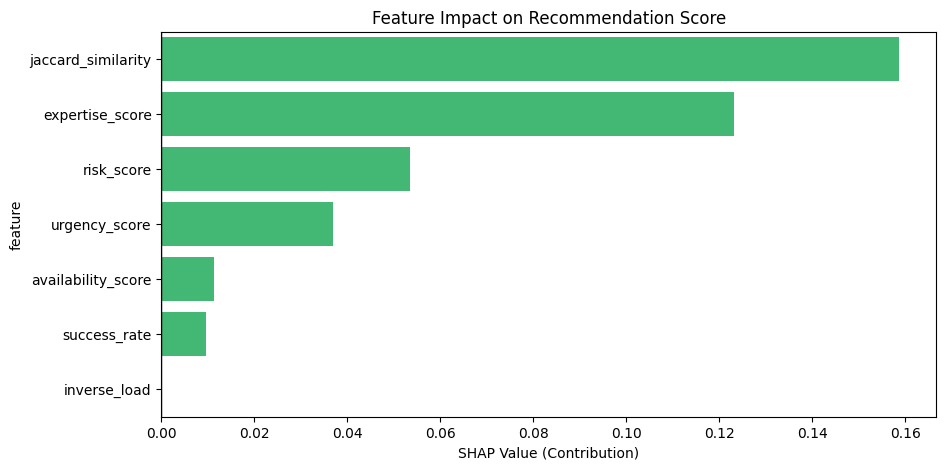

In [9]:
import numpy as np
import pandas as pd
import logging
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor

# ==========================================
# 1. Logger Setup
# ==========================================
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

# ==========================================
# 2. Simulated Model for SHAP (Since model isn't loaded)
# ==========================================
# We create a dummy model to demonstrate the SHAP logic
X_dummy = np.random.rand(100, 7)
y_dummy = X_dummy @ np.array([0.5, 0.2, 0.2, 0.3, 0.1, 0.1, 0.1]) + np.random.randn(100) * 0.01
model = GradientBoostingRegressor().fit(X_dummy, y_dummy)

# ==========================================
# 3. Feature Setup
# ==========================================
feature_names = [
    "jaccard_similarity", "risk_score", "urgency_score",
    "expertise_score", "success_rate", "availability_score", "inverse_load"
]

def build_features(p, d):
    # Ensure condition tags are sets
    p_tags = set(i.strip().lower() for i in str(p.get("condition_tags", "")).split(",") if i.strip())
    d_tags = set(i.strip().lower() for i in str(d.get("conditions_treated", "")).split(",") if i.strip())

    overlap = len(p_tags & d_tags)
    union = len(p_tags | d_tags) + 1e-6

    return [
        overlap / union,
        float(p.get("risk_score", 1.0)),
        float(p.get("urgency_score", 1.0)),
        float(d.get("expertise_score", 1.0)),
        float(d.get("success_rate", 0.8)),
        float(d.get("availability_score", 0.8)),
        float(1 - d.get("load_score", 0.5))
    ]

# ==========================================
# 4. MODERN SHAP EXPLAINER
# ==========================================
explainer = shap.Explainer(model, feature_names=feature_names)

# ==========================================
# 5. MAIN EXPLANATION FUNCTION
# ==========================================
def explain_single(patient_row, provider_row, debug=False):
    try:
        # Build features for the specific pair
        features_list = build_features(patient_row, provider_row)
        features_array = np.array(features_list, dtype=np.float32).reshape(1, -1)

        logger.info("Explaining Patient %s → Provider %s",
                    patient_row.get("patient_id", "N/A"),
                    provider_row.get("provider_id", "N/A"))

        # SHAP Explanation
        shap_values_obj = explainer(features_array)

        # Safe extraction for Modern API
        explanation_df = pd.DataFrame({
            "feature": feature_names,
            "value": features_array.flatten(),
            "shap_value": shap_values_obj.values[0]
        })

        explanation_df["impact"] = np.where(
            explanation_df["shap_value"] > 0, "↑ increases score", "↓ decreases score"
        )

        explanation_df = explanation_df.sort_values("shap_value", ascending=False)

        if debug:
            logger.info("Base value: %.4f", shap_values_obj.base_values[0])

        return explanation_df

    except Exception as e:
        logger.exception("SHAP explanation failed")
        raise

# ==========================================
# 6. VISUALIZATION FUNCTIONS
# ==========================================
def plot_shap_summary(explanation_df):
    plt.figure(figsize=(10, 5))
    colors = ["#2ecc71" if x > 0 else "#e74c3c" for x in explanation_df["shap_value"]]

    sns.barplot(data=explanation_df, x="shap_value", y="feature", palette=colors)
    plt.axvline(0, color='black', lw=1)
    plt.title("Feature Impact on Recommendation Score")
    plt.xlabel("SHAP Value (Contribution)")
    plt.show()

# ==========================================
# 7. RUN EXAMPLE (Simulated Data)
# ==========================================
# Mock data for demonstration
mock_patient = {"patient_id": "P-100", "condition_tags": "migraine", "risk_score": 4.5, "urgency_score": 3.0}
mock_provider = {"provider_id": "D-022", "conditions_treated": "migraine", "expertise_score": 4.8, "success_rate": 0.9, "availability_score": 0.7, "load_score": 0.2}

explanation = explain_single(mock_patient, mock_provider, debug=True)

print("\n--- Feature Impact Table ---")
print(explanation.to_string(index=False))

plot_shap_summary(explanation)


In [1]:
# ==========================================
# INSTALLS & SETUP
# ==========================================
!pip install fastapi uvicorn nest_asyncio pyngrok shap
import nest_asyncio
nest_asyncio.apply()

from fastapi import FastAPI, HTTPException, Query
import sqlite3
import numpy as np
import logging
import uvicorn
import threading
import sys
import asyncio
from pyngrok import ngrok
from google.colab import userdata

# ==========================================
# LOGGER (STRUCTURED)
# ==========================================
LOG_FORMAT = "%(asctime)s | %(levelname)s | %(name)s | %(message)s"
logging.basicConfig(level=logging.INFO, format=LOG_FORMAT, handlers=[logging.StreamHandler(sys.stdout)])
logger = logging.getLogger("health_api")

app = FastAPI(title="Healthcare Recommendation Engine (Explainable)")

# ==========================================
# NGROK & SERVER CONFIG
# ==========================================
NGROK_AUTH_TOKEN = userdata.get("ngrok")
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

def get_connection():
    return sqlite3.connect("healthcare.db", check_same_thread=False)

# ==========================================
# LOGIC: FEATURE & SCORING
# ==========================================
def build_features(patient, provider):
    # Ensure tags are clean sets
    p_tags = set(i.strip().lower() for i in str(patient.get("condition_tags", "")).split(",") if i.strip())
    d_tags = set(i.strip().lower() for i in str(provider.get("conditions_treated", "")).split(",") if i.strip())

    overlap = len(p_tags & d_tags)
    union = len(p_tags | d_tags) + 1e-6
    jaccard = overlap / union

    return [
        jaccard,
        float(patient.get("risk_score", 1.0)),
        float(patient.get("urgency_score", 1.0)),
        float(provider.get("expertise_score", 1.0)),
        float(provider.get("success_rate", 0.8)),
        float(provider.get("availability_score", 0.8)),
        float(1 - provider.get("load_score", 0.5)) # inverse load
    ]

def fallback_score(x):
    # Weights match your ranking logic
    # x[0]=jaccard, x[1]=risk, x[2]=urgency, x[3]=expertise, x[4]=success, x[5]=avail, x[6]=inv_load
    weighted_sum = (0.35*x[0] + 0.20*x[1] + 0.15*x[2] + 0.15*x[3] + 0.10*x[4] + 0.05*x[5])
    return weighted_sum * x[6]

# ==========================================
# ENDPOINTS
# ==========================================
@app.get("/")
def home():
    return {"status": "running", "api": "/recommend/{patient_id}"}

@app.get("/recommend/{patient_id}")
def recommend(patient_id: str, explain: bool = Query(False)):
    try:
        conn = get_connection()
        conn.row_factory = sqlite3.Row
        cur = conn.cursor()

        # 1. Fetch Patient
        p_row = cur.execute("SELECT * FROM patients WHERE patient_id=?", (patient_id,)).fetchone()
        if not p_row:
            raise HTTPException(status_code=404, detail="Patient not found")

        patient = dict(p_row)
        patient_tags = set(str(patient.get("condition_tags", "")).split(","))

        # 2. Fetch All Providers
        d_rows = cur.execute("SELECT * FROM providers").fetchall()

        results = []
        for row in d_rows:
            d = dict(row)
            d_tags = set(str(d.get("conditions_treated", "")).split(","))

            # 3. Calculate Features and Score
            features = build_features(patient, d)
            score = fallback_score(features)

            item = {
                "provider_id": d["provider_id"],
                "speciality": d.get("speciality", "General Physician"),
                "score": round(float(score), 4)
            }

            # 4. Explainability Logic
            if explain:
                common_conditions = list(patient_tags & d_tags)
                item["explanation"] = {
                    "matched_conditions": common_conditions,
                    "score_breakdown": {
                        "medical_fit_impact": round(0.35 * features[0], 3),
                        "expertise_impact": round(0.15 * features[3], 3),
                        "load_balancing_factor": round(features[6], 2)
                    },
                    "reason": f"Doctor specializes in {d.get('speciality')} and treats your condition(s): {', '.join(common_conditions)}" if common_conditions else "General match based on risk and availability."
                }

            results.append(item)

        # 5. Rank and return top 5
        ranked = sorted(results, key=lambda x: x["score"], reverse=True)[:5]

        logger.info(f"Generated {len(ranked)} recs for {patient_id}")
        return {
            "patient_id": patient_id,
            "patient_conditions": list(patient_tags),
            "recommendations": ranked
        }

    except Exception as e:
        logger.error(f"Logic Error: {str(e)}")
        raise HTTPException(status_code=500, detail=str(e))
    finally:
        conn.close()

# ==========================================
# SERVER RUNNER
# ==========================================
def start_api():
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
    server = uvicorn.Server(config)
    loop.run_until_complete(server.serve())

if __name__ == "__main__":
    !fuser -k 8000/tcp || true
    api_thread = threading.Thread(target=start_api, daemon=True)
    api_thread.start()

    try:
        public_url = ngrok.connect(8000)
        print(f"\n🚀 API LIVE at: {public_url.public_url}")
        print(f"🔗 Try Docs: {public_url.public_url}/docs")
        print(f"💡 Try Explainability: {public_url.public_url}/recommend/Patient_001?explain=true")
    except Exception as e:
        print(f"Ngrok failed: {e}")


INFO:     Started server process [52516]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)



🚀 API LIVE at: https://front-varying-unsteady.ngrok-free.dev
🔗 Try Docs: https://front-varying-unsteady.ngrok-free.dev/docs
💡 Try Explainability: https://front-varying-unsteady.ngrok-free.dev/recommend/Patient_001?explain=true
